# Does the bond market really "make room" before big Treasury auctions? 🏛️
### The auction concession — a rates-desk legend put on 47 years of tape, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Bigger auction bigger concession?: Busted](https://img.shields.io/badge/Bigger_auction_bigger_concession%3F-Busted-8b949e?style=flat-square)

Every month the U.S. government sells tens of billions of dollars of 10-year notes and 30-year bonds at **auction**, on a calendar published weeks in advance. The oldest story on any rates desk says the market **cheapens into** the auction — yields drift *up* for a few days because the dealers who must absorb all that paper demand a discount (a **concession**) — and then **richens after**, as the supply is digested and prices bounce back. A little V drawn on a thousand whiteboards.

We put the whole legend on tape: **every single 10Y and 30Y auction since 1979** — 825 of them, straight from the Treasury's official records — against daily yields.

> 📓 **Plain-language layer.** Want the HAC regressions, the size split and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_auction_concession import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    AU, YLDS, TLTF = data.load_real()
else:
    AU = YLDS = TLTF = None
print("real cache present:", HAVE_REAL,
      "| auctions:", (0 if AU is None else len(AU)),
      "| yield tape days:", (0 if YLDS is None else len(YLDS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp_yields': '388e6555b83b', 'fp_tlt': '7d6a23aca7db', 'n_auctions': 825, 'n_10y': 496, 'n_30y': 329, 'first': '1979-10-31', 'last': '2026-06-11', 'ten': {'10Y': (492, 1.55, -1.2, 0.0, 2.19, 0.324, 2.15, -0.283, -1.99), '30Y': (329, 2.18, -0.62, -0.49, 3.36, 0.548, 3.27, -0.08, -0.52)}, 'era': [('10Y', '1979-2007', 0.171, 0.53, -0.483, -1.77, 165), ('10Y', '2008-2019', 0.207, 0.97, -0.233, -1.06, 210), ('10Y', '2020-2026', 0.949, 3.39, 0.137, 0.44, 116), ('30Y', '1979-2007', 0.385, 0.8, -0.241, -0.63, 78), ('30Y', '2008-2019', 0.804, 3.86, -0.203, -0.94, 160), ('30Y', '2020-2026', 0.432, 1.41, 0.453, 1.52, 91)], 'size': {'10Y': (1.55, 308, 1.88, 180, -0.28, -1.2), '30Y': (2.25, 244, 0.9, 77, 0.92, -1.47)}, 'tlt': {'bh_excess': 3.01, 'alpha_base': -0.8, 'alpha_extra': 5.19, 't_alpha': 2.26, 'trips': 338, 'held': 38.5, 'per_trip': 30.0, 'cost': [(2.0, 4.25, 3.69, 2.11), (5.0, 4.25, 2.84, 1.63)], 'sub': [('2002-2019', 6.09, 5.54, 2.96, 236), ('2020-2026', -0.68, -1.32, -0.33, 102)]}, 'syn': [(0.0, -0.051, -0.29, -0.173, -1.04, 0.21, 0.14), (4.0, 0.749, 4.25, -0.973, -5.82, 8.35, 5.67)]}


real cache present: True | auctions: 825 | yield tape days: 16108


## The answer first

| Question | Answer |
|---|---|
| Do yields really drift up **into** big auctions? | **Yes — really.** About **+1.6 bps** into a 10Y auction and **+2.2 bps** into a 30Y, built over the auction week. Statistically solid on both, and *biggest* exactly when the government was issuing the most (after 2020). |
| Do they snap back **after**, like the legend says? | **Not reliably.** The bounce-back is small, misses the significance bar on both tenors, and has actually **flipped sign since 2020** — lately yields keep drifting *up* after auctions too. Half the legend fails. |
| Could you have traded the bounce? | **Once.** Buying the long-bond ETF (TLT) after each auction beat the couch-potato version handily from 2002–2019 — then the trade **died around 2020**. |
| Do **bigger** auctions get **bigger** concessions? | **No.** That's the story's own logic — more supply, more discount — and the tape says it just isn't there. |

> The concession is **real**; the *snap-back* and the *size logic* are folklore.

## 1 · The claim

> *"Treasury supply is perfectly predictable — the auction calendar is public. Dealers still need to be paid to warehouse it. So the market cheapens into every big 10Y/30Y auction and richens once the paper is placed."*

This isn't just trader talk — academics formalised it. Lou, Yan & Zhang (2013, *Review of Financial Studies*) documented a **V-shaped price pattern** around Treasury auctions: yields rise into the auction and fall back after, even though the event is anticipated to the day. The puzzle: in a perfectly efficient market, *anticipated* supply shouldn't move prices at all.

## 2 · So what?

If the concession is real, it means even the deepest market on Earth — U.S. Treasuries — pays a **storage fee** to intermediaries around predictable events: capital doesn't move fast enough to absorb $40bn of duration without a price cut. That matters for anyone timing bond purchases (buy on auction day, not the Friday before), for the Treasury's own issuance costs, and as a clean lab test of the *slow-moving capital* idea.

And if the V's second leg is real, there's a **tradable bounce**: buy the long bond at the auction close, sell a week later. We test both legs separately — legends usually hide one weak leg behind one strong one.

## 3 · How would we even know?

- **Every auction, officially.** All **825** 10Y-note and 30Y-bond auctions 1979-10-31 → 2026-06-11 from the Treasury's own FiscalData/TreasuryDirect records — including reopenings (a reopened 10Y is the same supply event). No survivorship possible: it's the complete government record.
- **Daily yields.** The 10Y (^TNX) and 30Y (^TYX) constant-maturity yield indices.
- **The windows.** *Pre* = the 5 trading days ending at the auction-day close (results hit at 1 pm, so that close knows the outcome). *Post* = the 5 days after.
- **The test.** Are pre-auction days different from ordinary days, once you account for the fact that market moves cluster? (That's the HAC regression in the quants notebook.)

## 4 · The teardown — let's actually look

**The V itself.** Average path of the 10Y and 30Y yield around their own auctions — day 0 is the auction-day close.

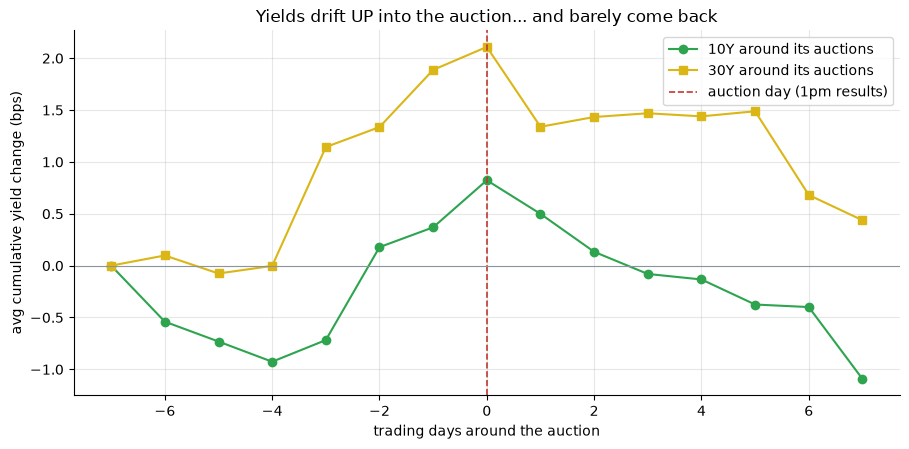

10Y: pre +1.55 bps  post -1.20 bps   30Y: pre +2.18 bps  post -0.62 bps


In [2]:
k = 7
if HAVE_REAL:
    p10 = st.car_profile(YLDS['y10'], AU.loc[AU['tenor']=='10Y','auction_date'], k=k)
    p30 = st.car_profile(YLDS['y30'], AU.loc[AU['tenor']=='30Y','auction_date'], k=k)
else:  # sketch from the frozen numbers
    ramp = np.r_[np.linspace(0, 1, k+1), np.linspace(1, 0, k)[1:]]
    p10 = pd.Series(ramp*R['ten']['10Y'][1], index=range(-k, k+1))
    p30 = pd.Series(ramp*R['ten']['30Y'][1], index=range(-k, k+1))
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(p10.index, p10.values, marker='o', color=GREEN, label='10Y around its auctions')
ax.plot(p30.index, p30.values, marker='s', color=AMBER, label='30Y around its auctions')
ax.axvline(0, color=RED, ls='--', lw=1.2, label='auction day (1pm results)')
ax.axhline(0, color=GREY, lw=.8)
ax.set_xlabel('trading days around the auction'); ax.set_ylabel('avg cumulative yield change (bps)')
ax.set_title('Yields drift UP into the auction... and barely come back')
ax.legend(); plt.tight_layout(); plt.show()
print(f'10Y: pre {p10[0]-p10[-5]:+.2f} bps  post {p10[5]-p10[0]:+.2f} bps   '
      f'30Y: pre {p30[0]-p30[-5]:+.2f} bps  post {p30[5]-p30[0]:+.2f} bps')

The **left half of the V is there**: on average the 10Y cheapens **+1.6 bps** and the 30Y **+2.2 bps** over the week into the auction (vs roughly flat ordinary weeks). The **right half is anaemic**: the bounce-back is **-1.2** / **-0.6 bps** — smaller than the build-up, and (the quants notebook shows) not statistically trustworthy. A tilted checkmark, not a V.

> 🔬 *For the quants:* the pre-leg clears the bar with HAC *t* = **2.15** (10Y) and **3.27** (30Y); the post-leg misses at *t* = -1.99 and -0.52.

**When did the concession live?** Split the 47 years into three regimes: before the GFC, the QE decade, and the post-2020 deficit flood.

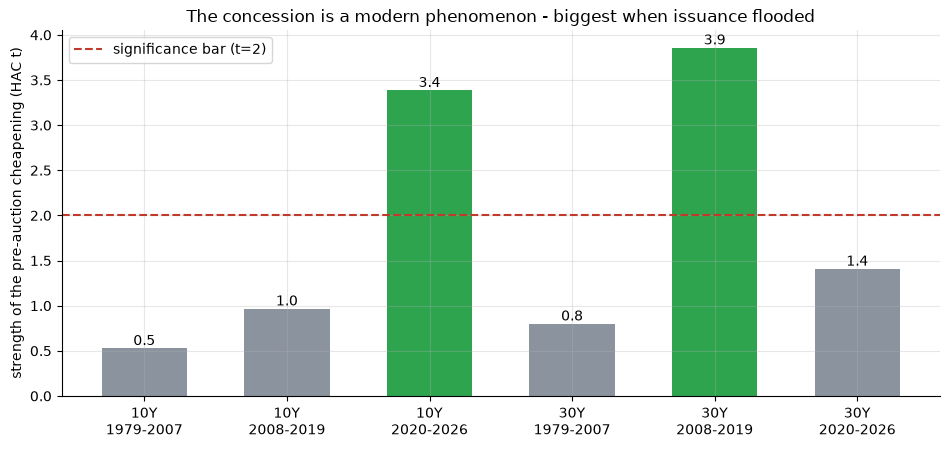

pre-leg HAC t by era: [('10Y 1979-2007', 0.53), ('10Y 2008-2019', 0.97), ('10Y 2020-2026', 3.39), ('30Y 1979-2007', 0.8), ('30Y 2008-2019', 3.86), ('30Y 2020-2026', 1.41)]


In [3]:
eras = [r for r in R['era']]
if HAVE_REAL:
    eras = []
    for tenor, col in [('10Y','y10'),('30Y','y30')]:
        for e in st.era_split(YLDS[col], AU.loc[AU['tenor']==tenor,'auction_date']):
            eras.append((tenor, e['era'], e['pre_bps_day'], e['t_pre'], e['post_bps_day'], e['t_post'], e['n_auctions']))
labels = [f"{t}\n{e}" for t,e,*_ in eras]
tvals = [r[3] for r in eras]
colors = [GREEN if v >= 2 else GREY for v in tvals]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(labels, tvals, color=colors, width=.6)
ax.axhline(2, ls='--', c=RED, label='significance bar (t=2)')
for i,v in enumerate(tvals): ax.annotate(f'{v:.1f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('strength of the pre-auction cheapening (HAC t)')
ax.set_title('The concession is a modern phenomenon - biggest when issuance flooded')
ax.legend(); plt.tight_layout(); plt.show()
print('pre-leg HAC t by era:', [(l.replace(chr(10),' '), round(v,2)) for l,v in zip(labels, tvals)])

Before 2008 the concession barely exists (*t* ≈ 0.5–0.8). It turns decisive in the **QE decade for the 30Y** (*t* = 3.9) and in the **post-2020 deficit flood for the 10Y** (*t* = 3.4 — nearly **5 bps** of cheapening per auction week). More supply pressure over time, more concession — the story's *era* logic holds.

But here's the twist: its *size* logic doesn't. Within any era, **bigger-than-usual auctions get no bigger concession than smaller ones** (10Y even points the wrong way). The market clears its throat before *every* auction, big or small — a calendar habit, not a dosage response.

**Could you trade the bounce?** Buy TLT (the 20+ year Treasury ETF) at each auction close, sell 5 days later, pay costs, park in T-bills otherwise.

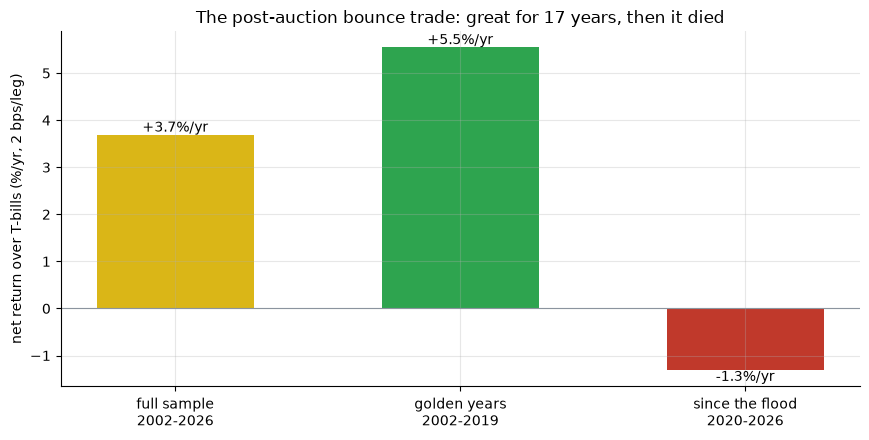

net %/yr (2bps/leg): [3.69, 5.54, -1.32]


In [4]:
if HAVE_REAL:
    full = st.tlt_post_auction(TLTF, AU['auction_date'], cost_bps=2.0)
    t1 = TLTF[TLTF.index <= '2019-12-31']; d1 = AU.loc[AU['auction_date'] <= '2019-12-31','auction_date']
    t2 = TLTF[TLTF.index >= '2020-01-01']; d2 = AU.loc[AU['auction_date'] >= '2020-01-01','auction_date']
    sub1 = st.tlt_post_auction(t1, d1, cost_bps=2.0)
    sub2 = st.tlt_post_auction(t2, d2, cost_bps=2.0)
    vals = [full['net_ann_pct'], sub1['net_ann_pct'], sub2['net_ann_pct']]
else:
    vals = [R['tlt']['cost'][0][2], R['tlt']['sub'][0][2], R['tlt']['sub'][1][2]]
labels = ['full sample\n2002-2026', 'golden years\n2002-2019', 'since the flood\n2020-2026']
colors = [AMBER, GREEN, RED]
fig, ax = plt.subplots(figsize=(8.8, 4.5))
ax.bar(labels, vals, color=colors, width=.55)
ax.axhline(0, color=GREY, lw=.8)
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('net return over T-bills (%/yr, 2 bps/leg)')
ax.set_title('The post-auction bounce trade: great for 17 years, then it died')
plt.tight_layout(); plt.show()
print('net %/yr (2bps/leg):', [round(v,2) for v in vals])

From 2002–2019 the bounce trade netted **+5.5%/yr over bills** while being in the market only ~2 weeks a month — genuinely good. Since 2020 it nets **-1.3%/yr**: the bounce is gone, exactly when the concession itself got biggest. Supply now cheapens the market into the auction *and it stays cheap* — nothing left to harvest on the other side.

## 5 · The verdict

- **Signal — Mixed.** The cheapen-into leg is **real**: +1.6 bps (10Y) and +2.2 bps (30Y) per auction week, statistically solid, strongest when issuance flooded. The richen-after leg **misses the bar** and has flipped sign since 2020. Half a legend confirmed.
- **Tradability — Fragile.** The post-auction TLT bounce beat bills convincingly for 17 years, then died in 2020. What remains (buy on auction day rather than the week before) is a *timing courtesy*, not a strategy.
- **"Bigger auction, bigger concession"? — Busted.** No dose-response anywhere on the tape. The concession follows the calendar, not the size of the print.

## 6 · Going further 🚪

- **If you buy Treasuries anyway**, the practical takeaway survives: scheduled purchases land ~1.5–3 bps cheaper on 10Y/30Y **auction days** than in the days before. Free, tiny, real.
- **Why did the bounce die?** Post-2020, supply is relentless and dealer balance sheets are capped — the concession stopped mean-reverting. Watch whether buybacks or dealer-regulation changes revive it.
- **Different plumbing, different studies:** the cash-futures basis trade ([382](../../382-treasury-basis-trade/README.md)), repo stress spikes ([383](../../383-sofr-repo-stress/README.md)) and curve roll-down ([380](../../380-curve-roll-down/README.md)) are separate Treasury-market legends on this bench.

*Think the concession should scale with auction size and we measured it wrong? The size split is one function call — bring a detrending you like better and show a Welch t above 2.*